# 8. Love Numbers with the Radial Solver

Tidal Love numbers describe how a body responds to a tidal potential: $k$ scales the induced gravity potential, $h$ the radial (vertical) surface displacement, and $l$ the tangential displacement. The 1D radial solver computes them from the interior structure: given each layer's density, complex moduli, and type, it integrates the six-component $y$ system from the center to the surface and reads the Love numbers off the surface boundary condition.

This notebook computes Love numbers for a layered terrestrial world and varies the two main modeling assumptions: compressible against incompressible, and static against dynamic (whether the body's own inertia is included). The solver has two engines: a shooting integrator for general compressible interiors, and a propagator matrix for the incompressible homogeneous limit, which is checked against a classical analytic result.

In [1]:
%matplotlib inline
import copy
import timeit
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.RadialSolver_x import radial_solver, homogeneous_love_numbers
from TidalPy.rheology_x import Maxwell, Elastic
from TidalPy.structures_x import build_world

def first(a):
    return complex(np.atleast_1d(a)[0])

def solve_layers(radius, density, cbulk, cshear, freq, bulk_density, types, is_static,
                 is_incompressible, upper_radii, degree_l=2, love_method='radial_solver'):
    "Run the radial solver and return (k, h, l, success)."
    sol = radial_solver(radius, density, cbulk, cshear, freq, bulk_density,
                        types, is_static, is_incompressible, upper_radii,
                        degree_l=degree_l, solve_for=("tidal",), love_method=love_method)
    return first(sol.k), first(sol.h), first(sol.l), sol.success

## A Two-Layer Terrestrial World

A dense stiff core under a rocky Maxwell mantle, forced at a one-day tidal period. The interface radius appears twice in the radius array, once as the top of the core and once as the base of the mantle. Solved with the shooting method (compressible), the Love numbers come out near Earth's values.

In [2]:
R = 6.371e6
R_core = 3.48e6
freq = 2.0 * np.pi / 86400.0     # one-day forcing

n_core = n_mantle = 80
radius = np.concatenate([np.linspace(0.0, R_core, n_core), np.linspace(R_core, R, n_mantle)])
in_core = np.arange(radius.size) < n_core

density = np.where(in_core, 10000.0, 4500.0)
bulk_density = 5510.0
shear = np.where(in_core, Elastic().calc_complex_modulus(200e9, 1e40, freq),
                          Maxwell().calc_complex_modulus(80e9, 1e21, freq))
bulk = np.where(in_core, 300.0e9 + 0j, 200.0e9 + 0j)
upper = np.array([R_core, R])
types = ("solid", "solid")

k, h, l, ok = solve_layers(radius, density, bulk, shear, freq, bulk_density,
                           types, (False, False), (False, False), upper)
print(f"success = {ok}")
print(f"k2 = {k.real:+.4f} {k.imag:+.2e}j")
print(f"h2 = {h.real:+.4f}")
print(f"l2 = {l.real:+.4f}")


success = True
k2 = +0.2746 -1.35e-07j
h2 = +0.5474
l2 = +0.1681


## Compressible vs Incompressible

For a homogeneous sphere the incompressible limit has a classical closed form (the Kelvin result), `k2 = 3/2 / (1 + 19 mu / (2 rho g R))`. The propagator-matrix engine reproduces it, and allowing compressibility (shooting) raises `k2` a little because the interior can also change volume.

In [3]:
N = 120
mu_h = Elastic().calc_complex_modulus(80.0e9, 1e40, freq)

# The package helper builds the homogeneous grid; the propagation matrix method handles the
# incompressible case and the shooting method the compressible one.
sol_i = homogeneous_love_numbers(R, bulk_density, mu_h, freq, num_slices=N,
                                 layer_is_incompressible=True, love_method='propagation_matrix')
sol_c = homogeneous_love_numbers(R, bulk_density, mu_h, freq, num_slices=N)
k_incomp = complex(np.atleast_1d(sol_i.k)[0])
k_comp = complex(np.atleast_1d(sol_c.k)[0])

g_surf = G * bulk_density * (4.0 / 3.0) * np.pi * R
k_analytic = 1.5 / (1.0 + 19.0 * 80.0e9 / (2.0 * bulk_density * g_surf * R))

print(f"incompressible (propagator matrix): k2 = {k_incomp.real:.5f}")
print(f"incompressible (analytic Kelvin)  : k2 = {k_analytic:.5f}")
print(f"compressible   (shooting)         : k2 = {k_comp.real:.5f}")


incompressible (propagator matrix): k2 = 0.46788
incompressible (analytic Kelvin)  : k2 = 0.46788
compressible   (shooting)         : k2 = 0.47556


## Static vs Dynamic

The dynamic solution keeps the body's own inertia and the static solution drops it. Sweeping the forcing period shows they agree at the long periods typical of tides and separate only toward very short periods, where inertia begins to matter.

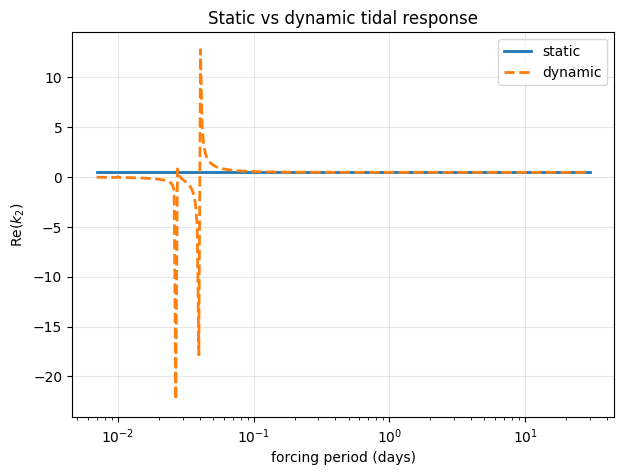

In [4]:
periods_s = np.logspace(np.log10(600.0), np.log10(30.0 * 86400.0), 300)   # 10 min to 30 days
k_static, k_dynamic = [], []
for p in periods_s:
    w = 2.0 * np.pi / p
    mu = Maxwell().calc_complex_modulus(80.0e9, 1.0e21, w)
    sol_s = homogeneous_love_numbers(R, bulk_density, mu, w, num_slices=N)
    sol_d = homogeneous_love_numbers(R, bulk_density, mu, w, num_slices=N, layer_is_static=False)
    k_static.append(complex(np.atleast_1d(sol_s.k)[0]).real)
    k_dynamic.append(complex(np.atleast_1d(sol_d.k)[0]).real)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(periods_s / 86400.0, k_static, lw=2, label="static")
ax.semilogx(periods_s / 86400.0, k_dynamic, "--", lw=2, label="dynamic")
ax.set_xlabel("forcing period (days)")
ax.set_ylabel(r"Re$(k_2)$")
ax.set_title("Static vs dynamic tidal response")
ax.legend(); ax.grid(alpha=0.3)
plt.show()


## Degree Dependence

Higher-degree tides probe shallower depths and produce progressively smaller Love numbers. The two-layer world's `k_l` falls off quickly with degree.

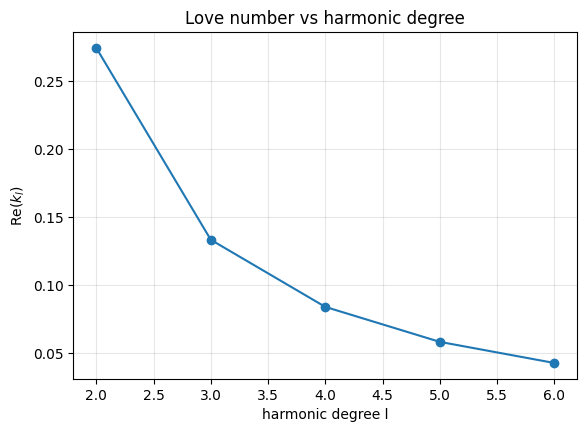

  l=2:  k = 0.2746
  l=3:  k = 0.1335
  l=4:  k = 0.0841
  l=5:  k = 0.0584
  l=6:  k = 0.0429


In [5]:
degrees = [2, 3, 4, 5, 6]
kl = []
for L in degrees:
    kL, *_ = solve_layers(radius, density, bulk, shear, freq, bulk_density,
                          types, (False, False), (False, False), upper, degree_l=L)
    kl.append(kL.real)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(degrees, kl, "o-")
ax.set_xlabel("harmonic degree l")
ax.set_ylabel(r"Re$(k_l)$")
ax.set_title("Love number vs harmonic degree")
ax.grid(alpha=0.3)
plt.show()
for L, v in zip(degrees, kl):
    print(f"  l={L}:  k = {v:.4f}")


## Love Numbers on a Built World

The examples above pass arrays directly to `radial_solver`. A world built from a bundled name, a TOML file, or a dict carries the same information in its layers: each layer's equation of state, viscosity, and rheology. `solve_eos()` integrates the structure once. `solve_love_numbers(frequency, degree_l)` then evaluates each layer's rheology at the forcing frequency \[rad s$^{-1}$\] and solves the radial problem on that structure.

The bundled `earth_simple` world has a solid inner core, a static liquid outer core, and an Andrade mantle. Its mantle shear modulus is fitted to $k_2 = 0.30$ at the semidiurnal M2 period (12.4206 hours).

The call returns a dict and also stores the results on the world:

- `love_number_k`, `love_number_h`, `love_number_l`: the complex Love numbers.
- `love_success`: whether the solve converged.
- `love_surface_amplification`: the conditioning of the surface boundary-condition solve. Values near 1 are healthy.
- `love_effective_shear_modulus`: the averaged shear modulus \[Pa\] used by the analytic methods in the next section. It is NaN after a radial-solver solve.

In [6]:
# Build the bundled three-layer Earth and solve its structure once
earth = build_world("earth_simple")
earth.solve_eos()

freq_m2 = 2.0 * np.pi / (12.4206 * 3600.0)   # M2 forcing frequency [rad s-1]

# Tidal Love numbers with the world's configured method (radial_solver by default)
result = earth.solve_love_numbers(
    frequency=freq_m2,
    degree_l=2)

k2 = earth.love_number_k
print(f"method                  = {earth.love_method}")
print(f"success                 = {earth.love_success}")
print(f"k2                      = {k2:.5f}")
print(f"h2                      = {earth.love_number_h:.5f}")
print(f"l2                      = {earth.love_number_l:.5f}")
print(f"Q = Re(k2) / -Im(k2)    = {k2.real / -k2.imag:.1f}")
print(f"surface amplification   = {earth.love_surface_amplification:.3f}")
print(f"effective shear modulus = {earth.love_effective_shear_modulus}")
print(f"result dict keys        = {list(result)}")

method                  = radial_solver
success                 = True
k2                      = 0.29996-0.00122j
h2                      = 0.63019-0.00224j
l2                      = 0.07543-0.00053j
Q = Re(k2) / -Im(k2)    = 246.3
surface amplification   = 3.228
effective shear modulus = (nan+0j)
result dict keys        = ['success', 'error_code', 'message', 'love_method', 'love_number_k', 'love_number_h', 'love_number_l']


## Love Methods on the Same World

`love_method` selects how the Love numbers are obtained. It can be passed per call, or set as the world default with `set_tide_config(love_method=...)` or the `love_method` key of the `[tides]` table.

- `radial_solver`: integrates the radial equations through every layer. Use it for layered interiors, liquid layers, and depth-dependent moduli.
- `homogeneous`: applies the homogeneous-sphere formula to the volume-averaged complex shear modulus of the `is_tidal` layers, with the planet's bulk density and surface gravity. It is a quick estimate that ignores layering, so here it misses the extra deformation allowed by the liquid outer core.
- `cpl` and `ctl`: use the homogeneous formula with the static shear modulus for $\mathrm{Re}(k_2)$, then set $-\mathrm{Im}(k_2) = \mathrm{Re}(k_2)/Q$ (constant phase lag) or $\mathrm{Re}(k_2)\,\omega\,\Delta t$ (constant time lag, $\Delta t$ \[s\]). Use them when a fixed $Q$ or time lag is the modeling assumption. $Q$ and $\Delta t$ come from the call (`fixed_q`, `fixed_dt`), then from `set_tide_config(love_fixed_q=..., love_fixed_dt=...)` or the `[tides]` keys `love_fixed_q` and `love_fixed_dt_s`, then from the attached tide model. A `ValueError` is raised when none of these supplies a value.
- `propagation_matrix`: valid only for a single solid, static, incompressible layer. On this three-layer world it fails without raising, with `love_success` False and the reason in `love_message`.

In [7]:
# Each method on the same solved world at the M2 frequency
method_settings = [
    ("radial_solver", {}),
    ("homogeneous", {}),
    ("cpl", {"fixed_q": 100.0}),          # constant phase lag with Q = 100
    ("ctl", {"fixed_dt": 600.0}),         # constant time lag of 600 s
    ("propagation_matrix", {}),
]

print(f"{'method':<20}{'success':>8}{'Re(k2)':>10}{'-Im(k2)':>11}{'Re(h2)':>9}{'mu_eff [GPa]':>22}")
for method, settings in method_settings:
    earth.solve_love_numbers(
        frequency=freq_m2,
        degree_l=2,
        love_method=method,
        **settings)
    k_method = earth.love_number_k
    # The averaged modulus is only defined for the analytic methods
    if method in ("homogeneous", "cpl", "ctl"):
        mu_eff = f"{earth.love_effective_shear_modulus / 1.0e9:.2f}"
    else:
        mu_eff = "-"
    print(f"{method:<20}{str(earth.love_success):>8}{k_method.real:>10.4f}{-k_method.imag:>11.2e}"
          f"{earth.love_number_h.real:>9.4f}{mu_eff:>22}")

print()
print("propagation_matrix message:", earth.love_message)

method               success    Re(k2)    -Im(k2)   Re(h2)          mu_eff [GPa]
radial_solver           True    0.3000   1.22e-03   0.6302                     -
homogeneous             True    0.2154   1.34e-03   0.3590          216.54+1.58j
cpl                     True    0.2127   2.13e-03   0.3546          219.69+0.00j
ctl                     True    0.2127   1.79e-02   0.3546          219.69+0.00j
propagation_matrix     False       nan  -0.00e+00      nan                     -

propagation_matrix message: TidalPy: the propagation-matrix method requires a single solid, static, incompressible layer.


## Tidal, Loading, and Free Love Numbers

`solve_for` selects the surface boundary condition. Both `solve_love_numbers` and the standalone `radial_solver` accept it, as one name or a tuple. A tuple solves every condition from one integration. `get_love_number_k(i)` (and the `_h` and `_l` versions) read condition `i` in the order requested, while the `love_number_*` properties report the first.

- `tidal`: the response to an external tidal potential.
- `loading`: the response to a surface mass load of the same degree. The load depresses the surface ($h' < 0$), and the displaced interior mass partly offsets the load's own potential ($k' < 0$).
- `free`: a stress-free surface with no forcing. Away from a normal-mode frequency its only solution is $y = 0$, which gives $k = -1$ and $h = l = 0$. It is used to search for free oscillations, not to describe a forced response.

In [8]:
# All three boundary conditions from one integration
boundary_conditions = ("tidal", "loading", "free")
earth.solve_love_numbers(
    frequency=freq_m2,
    degree_l=2,
    love_method="radial_solver",
    solve_for=boundary_conditions)

print(f"number of solved conditions = {earth.love_num_ytypes}")
print(f"{'condition':<10}{'k2':>26}{'h2':>26}{'l2':>26}")
for ytype_idx, condition in enumerate(boundary_conditions):
    k_bc = earth.get_love_number_k(ytype_idx)
    h_bc = earth.get_love_number_h(ytype_idx)
    l_bc = earth.get_love_number_l(ytype_idx)
    print(f"{condition:<10}{k_bc:>26.5f}{h_bc:>26.5f}{l_bc:>26.5f}")

number of solved conditions = 3
condition                         k2                        h2                        l2
tidal               0.29996-0.00122j          0.63019-0.00224j          0.07543-0.00053j
loading            -0.33023+0.00102j         -1.04879+0.00210j          0.04880+0.00052j
free               -1.00000+0.00000j          0.00000+0.00000j          0.00000+0.00000j


## Radial Functions from a World Solve

`get_love_radial_y(radius, ytype_idx, y_idx)` evaluates the last radial solve at any radius \[m\] from the solver's dense output. `y_idx` 0 to 5 selects $y_1$ to $y_6$, and `ytype_idx` selects the boundary condition in the order it was requested. The six functions are the radial and tangential displacements ($y_1$, $y_3$), the matching stresses ($y_2$, $y_4$), and the potential perturbation and its gradient term ($y_5$, $y_6$), all in SI units.

The static liquid outer core carries only the potential, so the displacements and stresses are NaN there and those curves break between 1221.5 and 3480 km. Values below the solver's starting radius near the center are also NaN.

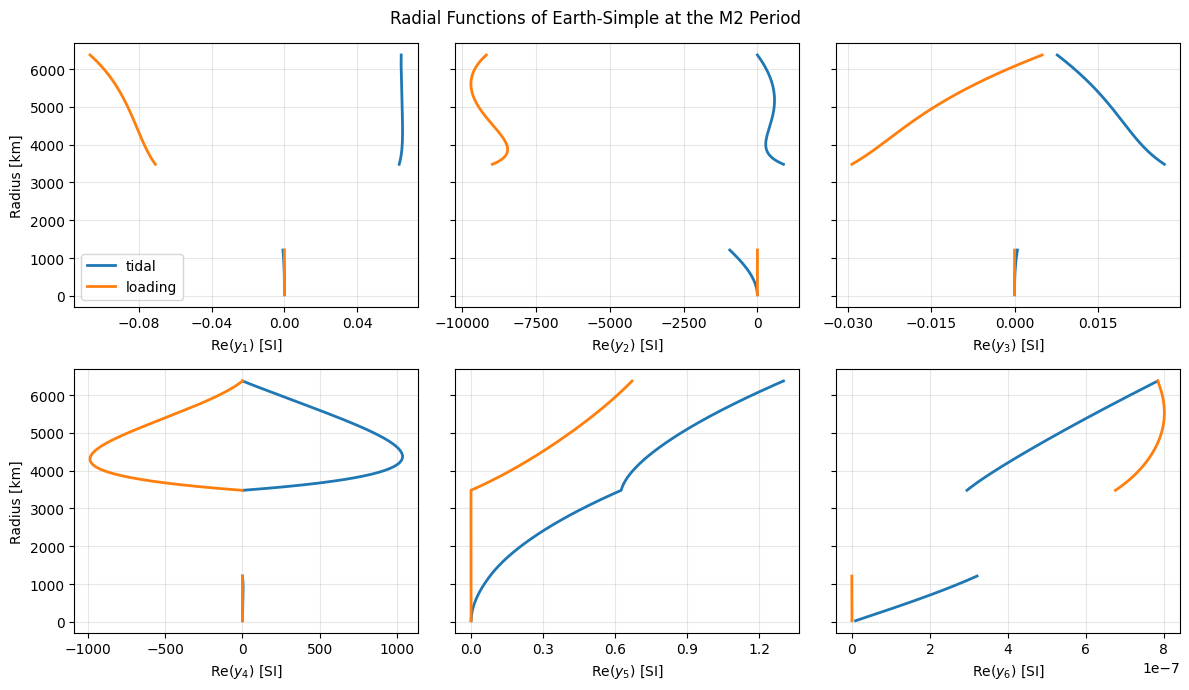

In [9]:
# Sample the tidal and loading solutions from the solve above across the whole radius
radii = np.linspace(1.0, 6.371e6, 400)   # [m]
y_labels = ["$y_1$", "$y_2$", "$y_3$", "$y_4$", "$y_5$", "$y_6$"]

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
for y_idx, ax in enumerate(axes.flat):
    for ytype_idx, condition in enumerate(("tidal", "loading")):
        y_values = np.array([earth.get_love_radial_y(radius, ytype_idx, y_idx) for radius in radii])
        ax.plot(y_values.real, radii / 1.0e3, lw=2, label=condition)
    ax.set_xlabel(f"Re({y_labels[y_idx]}) [SI]")
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))   # Keep the tick labels from overlapping
    ax.grid(alpha=0.3)
for ax in axes[:, 0]:
    ax.set_ylabel("Radius [km]")
axes[0, 0].legend()
fig.suptitle("Radial Functions of Earth-Simple at the M2 Period")
fig.tight_layout()
plt.show()

## Solution Diagnostics

The standalone `radial_solver` returns a `RadialSolverSolution` with more diagnostics than the world properties. Solving the two-layer world from the start of this notebook with both tidal and loading conditions gives one entry per condition in each of these:

- `Q_k`: the effective quality factor, $|\mathrm{Re}(k)| / (-\mathrm{Im}(k))$. For the loading case the imaginary part changes sign, so `Q_k` is negative and its magnitude is the loading quality factor.
- `lag_k`: the phase lag \[rad\], $\arctan(-\mathrm{Im}(k) / \mathrm{Re}(k))$.
- `surface_solve_amplification`: the same conditioning measure as `love_surface_amplification` above.

`print_diagnostics()` prints a summary of the equation of state and radial solves. `plot_interior()` plots gravity, density, pressure, and the moduli against radius. It calls `plt.show()` by default (`show_plot=True`) and returns the figure and axes.

k2 (tidal, loading)         = [ 0.27459858-1.35198396e-07j -0.27283391+1.22215775e-07j]
Q_k                         = [ 2031078.64262762 -2232395.21258644]
lag_k [rad]                 = [4.92349227e-07 4.47949357e-07]
surface solve amplification = 1.952

	Equation of State Solver:
		Success:           True
		Error code:        0
		Message:           Equation of state solver finished without issue.
		Iterations:        2
		Pressure Error:    4.455e-02
		Central Pressure:  2.879e+11
		Mass:              5.845e+24
		MOI:               8.384e+37 (factor 0.3534, sphere ratio 0.8835)
		Surface gravity:   9.612e+00

	Radial Solver Results:
		Success:     True
		Error code:  0
		Message:     RadialSolver.ShootingMethod: Completed without any noted issues.
		Steps Taken (per sub-solution):
			Layer 0 = [30 24 22]
			Layer 1 = [5 5 5]
		k_2 = [ 0.27459858-1.35198396e-07j -0.27283391+1.22215775e-07j]
		h_2 = [ 0.54743249-2.57414171e-07j -1.02561191+2.58806775e-07j]
		l_2 = [0.16810712-1.42662987e

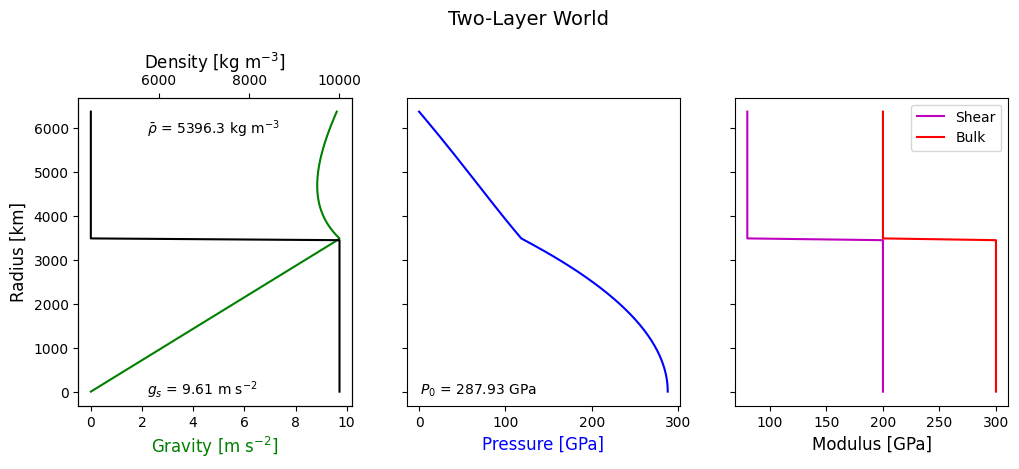

In [10]:
# Standalone solve of the two-layer world, tidal and loading together
solution = radial_solver(
    radius,
    density,
    bulk,
    shear,
    freq,
    bulk_density,
    types,
    (False, False),
    (False, False),
    upper,
    degree_l=2,
    solve_for=("tidal", "loading"))

print(f"k2 (tidal, loading)         = {solution.k}")
print(f"Q_k                         = {solution.Q_k}")
print(f"lag_k [rad]                 = {solution.lag_k}")
print(f"surface solve amplification = {solution.surface_solve_amplification:.3f}")
solution.print_diagnostics()

# Plot of the equation of state results: gravity, density, pressure, and moduli
fig, axes = solution.plot_interior(planet_name="Two-Layer World")

## Frequency Dependence

The complex Love number depends on the forcing frequency through each layer's rheology. The sweep below runs from a 1 hour to a 1000 year forcing period on `earth_simple` and on a copy whose mantle uses a Maxwell rheology. The copy is built from `earth.get_config_dict()` with the mantle's `shear_rheology` table replaced, which shows the dict path of `build_world`.

The mantle viscosity of $10^{21}$ \[Pa s\] and shear modulus of $2.2 \times 10^{11}$ \[Pa\] give a Maxwell time of about 140 years. At periods well below it the Maxwell mantle is nearly elastic, and its $-\mathrm{Im}(k_2)$ grows in proportion to the period. The Andrade transient creep adds dissipation across the tidal band, so the Andrade $-\mathrm{Im}(k_2)$ is several orders of magnitude larger at the M2 period and grows more slowly with period. Each world solve reuses the cached structure, so the 242 solves take well under a second.

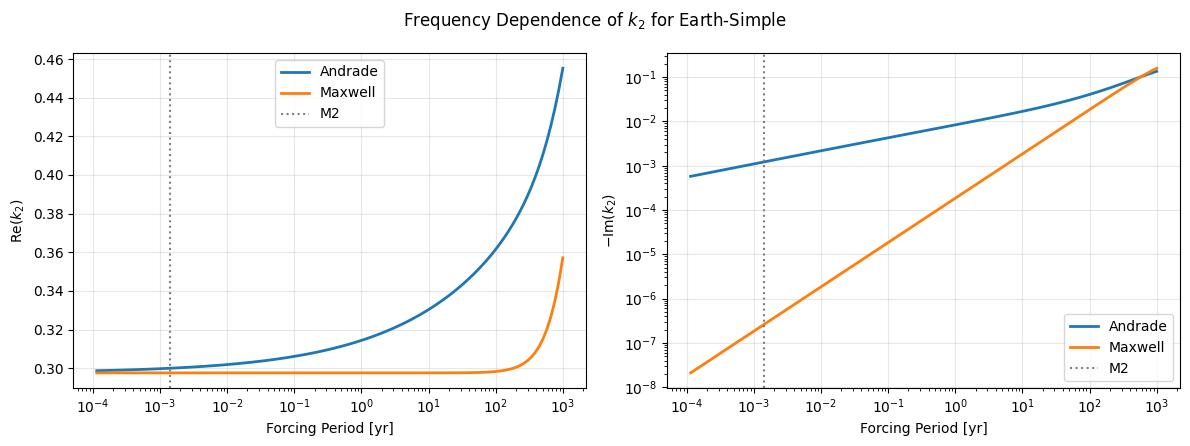

Andrade  k2 at 1 hr = 2.987e-01-5.749e-04j, at M2 = 3.000e-01-1.218e-03j, at 1000 yr = 4.552e-01-1.351e-01j
Maxwell  k2 at 1 hr = 2.976e-01-2.106e-08j, at M2 = 2.976e-01-2.616e-07j, at 1000 yr = 3.571e-01-1.586e-01j


In [11]:
# A Maxwell-mantle copy of Earth-Simple built from a config dict
maxwell_config = copy.deepcopy(earth.get_config_dict())
maxwell_config["name"] = "Earth-Simple-Maxwell"
maxwell_config["layers"]["mantle"]["shear_rheology"] = {"model": "maxwell"}
earth_maxwell = build_world(maxwell_config)
earth_maxwell.solve_eos()

year = 365.25 * 86400.0   # [s]
period_m2 = 12.4206 * 3600.0   # [s]
# 1 hour to 1000 years [s], with the M2 period included
periods = np.sort(np.append(np.logspace(np.log10(3600.0), np.log10(1000.0 * year), 120), period_m2))

k2_sweeps = {}
for label, world in (("Andrade", earth), ("Maxwell", earth_maxwell)):
    k2_values = np.empty(periods.size, dtype=np.complex128)
    for period_idx, period in enumerate(periods):
        world.solve_love_numbers(
            frequency=2.0 * np.pi / period,
            degree_l=2,
            love_method="radial_solver")
        k2_values[period_idx] = world.love_number_k if world.love_success else np.nan
    k2_sweeps[label] = k2_values

fig, (ax_real, ax_imag) = plt.subplots(1, 2, figsize=(12, 4.5))
for label, k2_values in k2_sweeps.items():
    ax_real.semilogx(periods / year, k2_values.real, lw=2, label=label)
    ax_imag.loglog(periods / year, -k2_values.imag, lw=2, label=label)
for ax in (ax_real, ax_imag):
    ax.axvline(period_m2 / year, color="gray", ls=":", label="M2")
    ax.set_xlabel("Forcing Period [yr]")
    ax.grid(alpha=0.3)
    ax.legend()
ax_real.set_ylabel(r"Re$(k_2)$")
ax_imag.set_ylabel(r"$-$Im$(k_2)$")
fig.suptitle("Frequency Dependence of $k_2$ for Earth-Simple")
fig.tight_layout()
plt.show()

m2_idx = np.flatnonzero(periods == period_m2)[0]
for label, k2_values in k2_sweeps.items():
    print(f"{label:<8} k2 at 1 hr = {k2_values[0]:.3e}, at M2 = {k2_values[m2_idx]:.3e}, "
          f"at 1000 yr = {k2_values[-1]:.3e}")